# 🏁 Playground · Comparativa de modelos y visualización 2D (PLS)

⚠️ Este notebook es **autónomo**: **no** importa nada de `src/`. Todo el código vive aquí, igual que en los notebooks de `recursos/`.

> Reunimos en un mismo sitio los modelos que entrenamos por separado (`03` supervisados, `04` red neuronal) para **compararlos con la misma vara** y, sobre todo, para **verlos**: proyectamos las ~150 *features* a un **plano 2D supervisado (PLS)** y dibujamos las **regiones de decisión** de cada modelo. Así se entiende *visualmente* por qué unos separan mejor las cancelaciones que otros.

## 0. Configuración

Importamos librerías y cargamos el dataset ya procesado por [`02_preparacion_datos.ipynb`](02_preparacion_datos.ipynb) (`train`/`test` separados, *fit-on-train*). Igual que en `03` y `04`, aquí solo **modelamos y comparamos**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

import warnings; warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve)
from xgboost import XGBClassifier
from matplotlib.colors import ListedColormap

RANDOM_STATE = 42
target_column = 'is_canceled'
list_nombres_clases = ['No cancela', 'Cancela']

In [2]:
PATH_DIRECTORIO_DATOS = "../../data/processed"
train_df = pd.read_csv(f"{PATH_DIRECTORIO_DATOS}/train.csv")
test_df = pd.read_csv(f"{PATH_DIRECTORIO_DATOS}/test.csv")

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column]
X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column]
assert list(X_train.columns) == list(X_test.columns), "Columnas train/test no coinciden"

print('Train:', X_train.shape, '| Test:', X_test.shape, '| nº features:', X_train.shape[1])

Train: (94850, 155) | Test: (23713, 155) | nº features: 155


## 1. Entrenamos los cinco modelos

Los mismos cinco de los notebooks anteriores, con hiperparámetros sensatos (sin optimizar aquí): **Regresión Logística**, **Árbol de Decisión**, **Random Forest**, **XGBoost** y una **Red neuronal (MLP)**. Para la red usamos el `MLPClassifier` de *scikit-learn* (no Keras): así todo el cuaderno comparte la misma API `fit`/`predict_proba` y la comparación es directa.

> La red y la regresión logística agradecen el **escalado**; los árboles no lo necesitan. Para no complicar, entrenamos los modelos que escalan sobre datos escalados (`StandardScaler` *fit-on-train*) y los de árbol sobre los datos tal cual.

In [3]:
# Escalado fit-on-train (lo usan LogReg y MLP)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

modelos = {
    "Regresión Logística": (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    "Árbol de Decisión":   (DecisionTreeClassifier(max_depth=12, min_samples_leaf=50, random_state=RANDOM_STATE), False),
    "Random Forest":       (RandomForestClassifier(n_estimators=200, max_depth=18, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE), False),
    "XGBoost":             (XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE), False),
    "Red neuronal (MLP)":  (MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, random_state=RANDOM_STATE), True),
}

resultados, probas = [], {}
for nombre, (modelo, escala) in modelos.items():
    Xtr, Xte = (X_train_s, X_test_s) if escala else (X_train, X_test)
    modelo.fit(Xtr, y_train)
    p = modelo.predict_proba(Xte)[:, 1]
    pred = (p >= 0.5).astype(int)
    probas[nombre] = p
    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, p),
    })
    print(f"  {nombre:<22} ROC-AUC={resultados[-1]['roc_auc']:.4f}")

  Regresión Logística    ROC-AUC=0.8926


  Árbol de Decisión      ROC-AUC=0.9199


  Random Forest          ROC-AUC=0.9296


  XGBoost                ROC-AUC=0.9486


  Red neuronal (MLP)     ROC-AUC=0.9345


## 2. Tabla comparativa

Ordenamos por **ROC-AUC** (nuestra métrica principal: el problema está desbalanceado y el *accuracy* engaña).

In [4]:
df_resultados = (pd.DataFrame(resultados)
                 .sort_values("roc_auc", ascending=False)
                 .reset_index(drop=True))
df_resultados.round(4)

,modelo,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.8757,0.8595,0.7967,0.8269,0.9486
1,Red neuronal (MLP),0.8602,0.8218,0.7977,0.8096,0.9345
2,Random Forest,0.8515,0.8817,0.6945,0.7770,0.9296
3,Árbol de Decisión,0.8427,0.8171,0.7443,0.7790,0.9199
4,Regresión Logística,0.8121,0.8022,0.6580,0.7230,0.8926


### Gráfica de barras (ROC-AUC por modelo)

In [5]:
orden = df_resultados.sort_values("roc_auc")  # ascendente para barh de mayor a menor visualmente
fig = px.bar(orden, x="roc_auc", y="modelo", orientation="h", text_auto=".4f",
             title="Comparativa de modelos por ROC-AUC",
             labels={"roc_auc": "ROC-AUC", "modelo": ""}, width=760, height=420)
fig.update_xaxes(range=[0.85, 1.0])
fig.show(renderer='notebook_connected')

## 3. Curvas ROC superpuestas

Cada curva enfrenta la tasa de verdaderos positivos (TPR) frente a la de falsos positivos (FPR) al variar el umbral. Cuanto más **arriba y a la izquierda**, mejor; la diagonal es el azar (AUC = 0.5).

In [6]:
fig = go.Figure()
for nombre in df_resultados["modelo"]:
    fpr, tpr, _ = roc_curve(y_test, probas[nombre])
    auc = roc_auc_score(y_test, probas[nombre])
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f"{nombre} ({auc:.3f})"))
fig.add_shape(type='line', line=dict(dash='dash', color='grey'), x0=0, x1=1, y0=0, y1=1)
fig.update_layout(title="Curvas ROC de los cinco modelos",
                  xaxis_title="FPR (falsos positivos)", yaxis_title="TPR (verdaderos positivos)",
                  width=720, height=560, legend=dict(x=0.55, y=0.08))
fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.show(renderer='notebook_connected')

## 4. Visualización 2D: regiones de decisión con PLS supervisado

Nuestros datos tienen **~150 dimensiones**: imposible de dibujar. Para *verlos*, hay que **proyectarlos a 2D**. ¿Por qué **PLS** y no PCA?

- **PCA** busca las direcciones de **máxima varianza** de las `X` — **ignora el target**. A menudo la varianza grande no es la que separa cancela/no-cancela, y las dos clases salen mezcladas.
- **PLS** (*Partial Least Squares*) busca las direcciones de `X` **más correlacionadas con `y`**. Es una proyección **supervisada**: usa la etiqueta, así que tiende a **separar las clases** en el plano.

El plan: proyectar a **2 componentes PLS**, **reentrenar** cada modelo *sobre esas 2 componentes*, y pintar sus **regiones de decisión** en **una fila de 5** (el color de fondo = probabilidad de cancelación que asigna el modelo a cada punto del plano). Encima, una muestra de reservas reales de test (azul = no canceló, rojo = canceló). Esta figura se guarda como PNG para usarla de **recurso visual** en documentación y frontend.

> ⚠️ **Ojo (igual que en `02`/`03`): PLS usa el target.** Lo ajustamos **solo con `train`** y proyectamos `test` con esa misma transformación; si no, habría fuga. Esto es una **herramienta de visualización**, no el modelo de producción: cada modelo aquí se reentrena sobre 2 variables y rinde algo peor que con las 150.

In [7]:
# 1) PLS supervisado (fit SOLO en train) sobre los datos escalados
pls = PLSRegression(n_components=2).fit(X_train_s, y_train.values)
C_train = pls.transform(X_train_s)
C_test = pls.transform(X_test_s)

# 2) Orientamos el eje 1 hacia 'más riesgo' (rojo a la derecha), sea cual sea el signo de PLS
mean_pos = C_train[y_train.values == 1, 0].mean()
mean_neg = C_train[y_train.values == 0, 0].mean()
if mean_pos < mean_neg:
    C_train[:, 0] *= -1
    C_test[:, 0] *= -1

# 3) Reentrenamos los 5 modelos SOBRE las 2 componentes PLS
modelos_2d = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Árbol de Decisión":   DecisionTreeClassifier(max_depth=12, min_samples_leaf=50, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=18, min_samples_leaf=20, n_jobs=-1, random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, subsample=0.9, colsample_bytree=0.9, eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE),
    "Red neuronal (MLP)":  MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=400, random_state=RANDOM_STATE),
}
for m in modelos_2d.values():
    m.fit(C_train, y_train.values)

print("PLS ajustado y 5 modelos reentrenados sobre el plano 2D.")

PLS ajustado y 5 modelos reentrenados sobre el plano 2D.


Figura guardada en /home/manu/dev/github.com/manupm87/pontia-ml/outputs/playground_regiones_pls.png


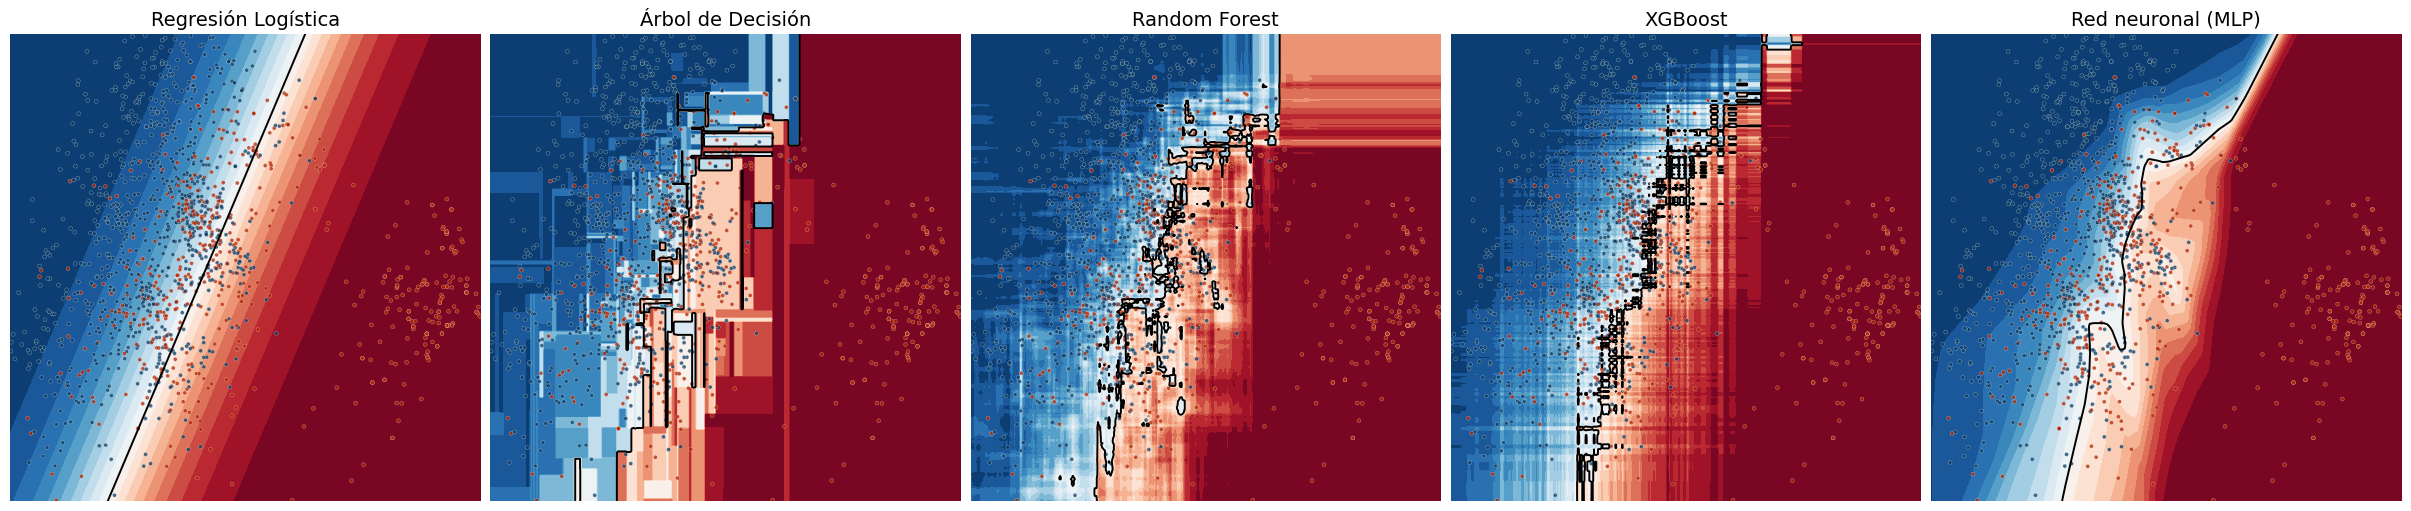

In [8]:
# 4) Rejilla del plano. La recortamos a percentiles 1-99 para que algún outlier
# no estire el plano; y FIJAMOS los límites de cada eje a ese mismo rango para que
# el fondo (contourf) cubra TODA la subgráfica, sin márgenes blancos.
x0, x1 = np.percentile(C_train[:, 0], [1, 99])
y0, y1 = np.percentile(C_train[:, 1], [1, 99])
xx, yy = np.meshgrid(np.linspace(x0, x1, 300), np.linspace(y0, y1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Submuestra fija de test para el scatter; recortada al rango del plano para no
# arrastrar los límites de los ejes fuera de la zona pintada.
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(C_test), min(1500, len(C_test)), replace=False)
pts, lbl = C_test[idx], y_test.values[idx]
dentro = (pts[:, 0] >= x0) & (pts[:, 0] <= x1) & (pts[:, 1] >= y0) & (pts[:, 1] <= y1)
pts, lbl = pts[dentro], lbl[dentro]

# 5) Figura: los 5 modelos en una fila. Recurso visual LIMPIO (sin título, ejes ni
# leyenda): solo la visualización y el nombre del modelo, para docs/frontend.
cmap_pts = ListedColormap(["#0b3d66", "#b32400"])  # azul=no cancela, rojo=cancela
levels = np.linspace(0, 1, 21)
fig, axes = plt.subplots(1, 5, figsize=(24, 5), constrained_layout=True)
for ax, (nombre, modelo) in zip(axes, modelos_2d.items()):
    pg = modelo.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, pg, levels=levels, cmap="RdBu_r", vmin=0, vmax=1)
    ax.contour(xx, yy, pg, levels=[0.5], colors="k", linewidths=1.4)
    ax.scatter(pts[:, 0], pts[:, 1], c=lbl, cmap=cmap_pts, s=8,
               edgecolor="white", linewidth=0.2, alpha=0.75)
    ax.set_title(nombre, fontsize=14)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)   # <- el fondo cubre toda la subgráfica
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Guardamos el PNG como recurso reutilizable (documentación / frontend).
import pathlib
out_png = pathlib.Path("../../outputs/playground_regiones_pls.png")
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=130, bbox_inches="tight")
print("Figura guardada en", out_png.resolve())
plt.show()

**Cómo leer estos mapas.**

- El **fondo** es lo que cree cada modelo: **rojo** = "aquí se cancela", **azul** = "aquí no". La línea negra es la **frontera de decisión** (probabilidad 0.5).
- Los **puntos** son reservas reales de test (**azul** = no canceló, **rojo** = canceló). Un modelo acierta cuando los puntos rojos caen sobre fondo rojo y los azules sobre fondo azul.
- Que las dos nubes de puntos **se separen** ya en 2D confirma que el problema es aprendible: PLS encuentra una dirección (eje 1) que **ordena el riesgo** de cancelación.
- **Forma de las fronteras:** la **Regresión Logística** traza una frontera casi **recta** (modelo lineal); el **Árbol** hace cortes **rectangulares**; **Random Forest** y **XGBoost** dibujan fronteras **suaves y curvas** que se ajustan mejor a la nube; la **red neuronal** también curva, de forma más blanda. Es la misma jerarquía que vimos en las métricas, ahora **a la vista**.

> 💾 La figura se guarda además como `outputs/playground_regiones_pls.png`, lista para reutilizar en la **documentación** y el **frontend**.

## 5. Conclusiones

- Con la **misma vara** (ROC-AUC sobre el test ya preparado), **XGBoost** queda primero, seguido de cerca por Random Forest y la red; la Regresión Logística va por detrás por ser lineal.
- Las **curvas ROC** superpuestas cuentan lo mismo de un vistazo: la de XGBoost domina (más arriba-izquierda).
- La **proyección PLS** nos deja *ver* el porqué: en el plano supervisado las clases se separan, y los modelos más potentes dibujan **fronteras más flexibles** que envuelven mejor la zona de cancelación.
- Recordatorio: el plano 2D es para **entender**, no para producir. El modelo real usa las ~150 *features*; aquí cada modelo se reentrena con solo 2 componentes y por eso rinde algo menos. (Y seguimos arrastrando la **fuga por duplicación** del `02`, que infla un poco todas las métricas.)

> Con esto cerramos la parte de modelado supervisado del *playground*. El siguiente paso natural es **interpretar** el modelo ganador (`07`, SHAP) y, en el `06`, ver cómo afecta el **balanceo de clases**.